In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [16]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "embarked", "fare", "age"]
target =["survived"]

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.3, random_state=42
)

In [17]:

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy score: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy score: ", accuracy_score(y_test, y_pred_test)*100, "%")
# very overfitting

Training accuracy score:  97.91332263242376 %
Testing accuracy score:  75.0 %


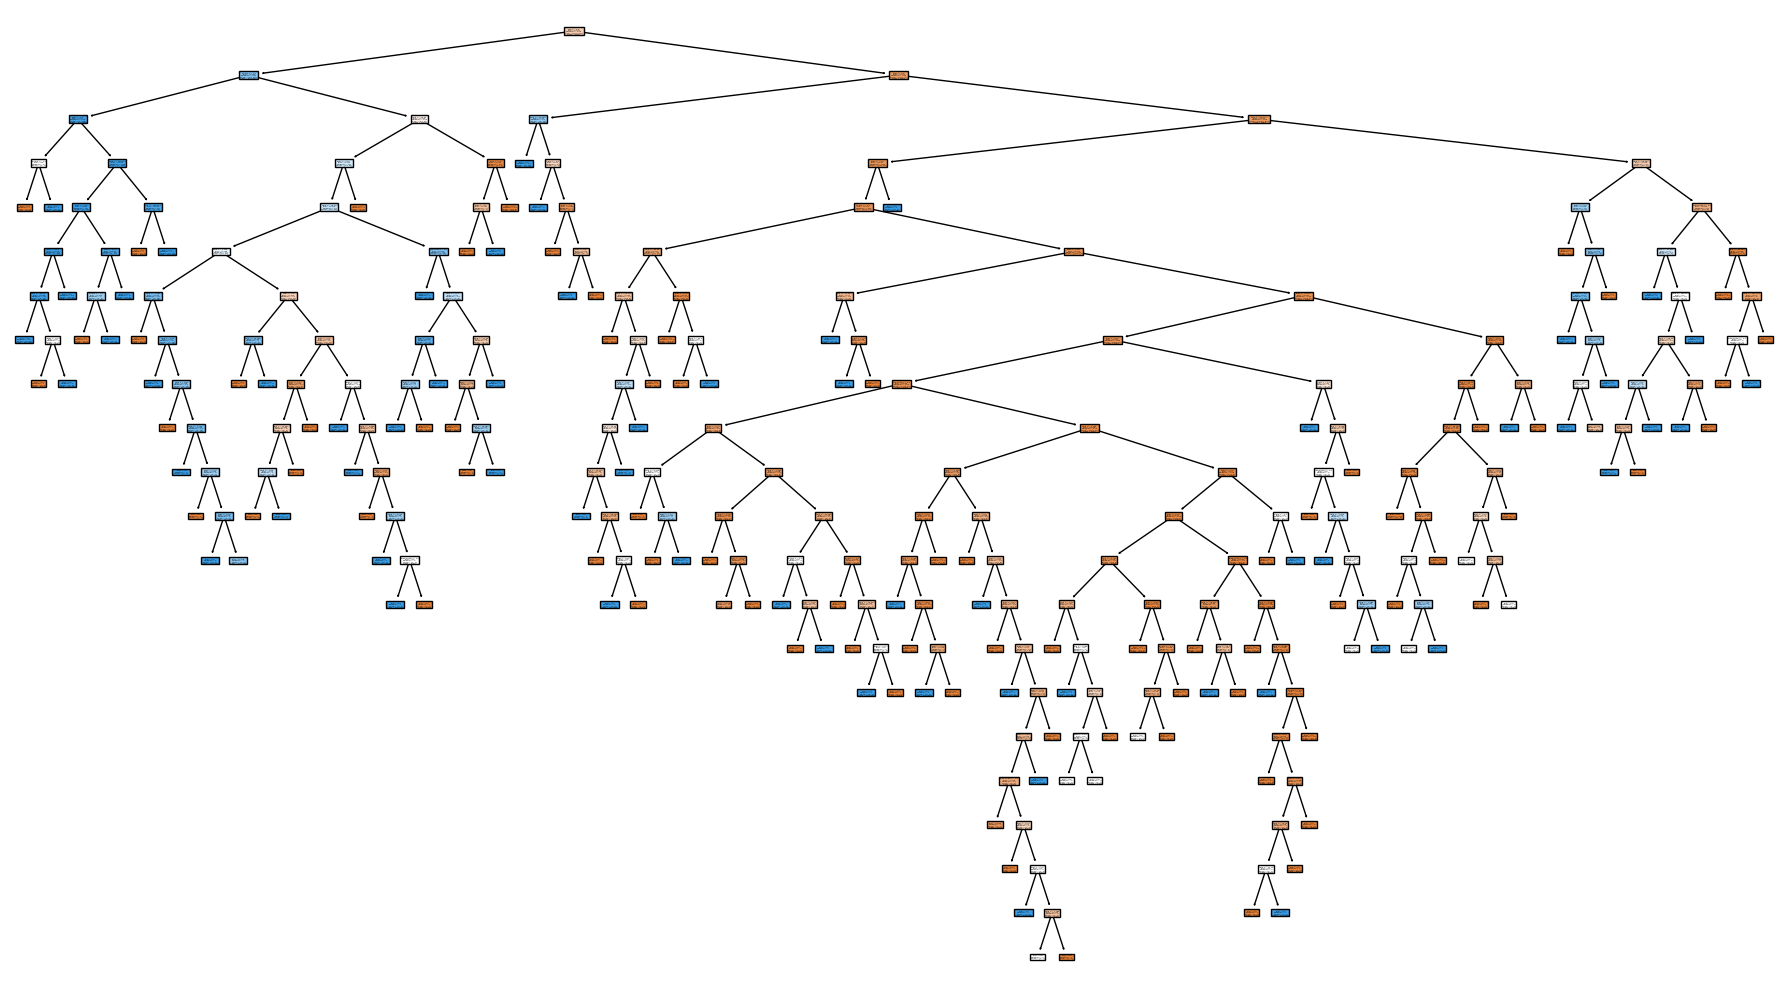

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    # max_depth=4
)

plt.tight_layout()
plt.show()

In [22]:
# Random Forest Classifier

rfc = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print("testig accuracy", accuracy_score(y_test, y_pred)*100)
print("OOB score", rfc.oob_score_*100)

# more stable than DT, as that gave 97.9 compared to OOB that gave 81

testig accuracy 78.73134328358209
OOB score 81.05939004815409


In [ ]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=405,
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test) 
print("accuracy score: ", accuracy_score(y_test, y_pred))

accuracy score:  0.7910447761194029


In [27]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

model = LogisticRegression()

bagging = BaggingClassifier(
    model,
    n_estimators=502
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test) 
print("accuracy score: ", accuracy_score(y_test, y_pred))

accuracy score:  0.7947761194029851


In [29]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

bagging = BaggingClassifier(
    model,
    n_estimators=502
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test) 
print("accuracy score: ", accuracy_score(y_test, y_pred))

accuracy score:  0.7052238805970149
